# **CP462 Project**
# หัวข้อ : **Preparedness website vulnerability annlysis**
สมาชิก:
1) นายพชรพล เพ็ชรชูชาติ  (ID : 666102010146 )
2) นายประภากร คล้อยโท้ (ID : 66102010144)
3) นายแอนดี้ ทองขลิบ    (ID : 66102010247 )


## **Data Wrangling** ---------------------------------------------------------------------------

# Gathering / Data Acquisition

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

df = pd.read_csv('/content/cve.csv', engine='python')

 ดู 5 แถวแรก

In [ ]:
# ดู 5 แถวแรก
print("=== Head (5 rows) ===")
print(df.head())

=== Head (5 rows) ===
       Unnamed: 0             mod_date             pub_date  cvss  cwe_code  \
0  CVE-2019-16548  2019-11-21 15:15:00  2019-11-21 15:15:00   6.8       352   
1  CVE-2019-16547  2019-11-21 15:15:00  2019-11-21 15:15:00   4.0       732   
2  CVE-2019-16546  2019-11-21 15:15:00  2019-11-21 15:15:00   4.3       639   
3   CVE-2013-2092  2019-11-20 21:22:00  2019-11-20 21:15:00   4.3        79   
4   CVE-2013-2091  2019-11-20 20:15:00  2019-11-20 20:15:00   7.5        89   

                                            cwe_name  \
0                  Cross-Site Request Forgery (CSRF)   
1   Incorrect Permission Assignment for Critical ...   
2   Authorization Bypass Through User-Controlled Key   
3   Improper Neutralization of Input During Web P...   
4   Improper Neutralization of Special Elements u...   

                                             summary access_authentication  \
0  A cross-site request forgery vulnerability in ...                   NaN   
1  Missing

ดู column + datatype

In [ ]:
# ดู column + datatype
print("\n=== Info (column & datatype) ===")
print(df.info())


=== Info (column & datatype) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89660 entries, 0 to 89659
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              89660 non-null  object 
 1   mod_date                89660 non-null  object 
 2   pub_date                89660 non-null  object 
 3   cvss                    89660 non-null  float64
 4   cwe_code                89660 non-null  int64  
 5   cwe_name                89660 non-null  object 
 6   summary                 89660 non-null  object 
 7   access_authentication   88776 non-null  object 
 8   access_complexity       88776 non-null  object 
 9   access_vector           88776 non-null  object 
 10  impact_availability     88776 non-null  object 
 11  impact_confidentiality  88776 non-null  object 
 12  impact_integrity        88776 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 8.9+ MB

In [ ]:
print(df.describe())

               cvss      cwe_code
count  89660.000000  89660.000000
mean       6.021429    199.690854
std        1.994757    176.177244
min        0.000000      1.000000
25%        4.300000     79.000000
50%        5.800000    119.000000
75%        7.500000    284.000000
max       10.000000   1188.000000


In [ ]:
df.describe(include='all') #include mean std max min IQR

,Unnamed: 0,mod_date,pub_date,cvss,cwe_code,cwe_name,summary,access_authentication,access_complexity,access_vector,impact_availability,impact_confidentiality,impact_integrity
count,89660,89660,89660,89660.000000,89660.000000,89660,89660,88776,88776,88776,88776,88776,88776
unique,89660,33173,13235,NaN,NaN,170,87432,3,3,3,3,3,3
top,CVE-2007-3004,2019-10-03 00:03:00,2018-07-09 06:29:00,NaN,NaN,Improper Restriction of Operations within the...,A remote code execution vulnerability was iden...,NONE,LOW,NETWORK,PARTIAL,PARTIAL,PARTIAL
freq,1,3641,322,NaN,NaN,12344,83,76777,45746,76104,35991,42039,46357
mean,NaN,NaN,NaN,6.021429,199.690854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.994757,176.177244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,4.300000,79.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,5.800000,119.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,7.500000,284.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ดู missing values ของทุก column


In [ ]:
# ดู missing values ของทุก column
print("\n=== Missing Values per column ===")
print(df.isnull().sum())


=== Missing Values per column ===
Unnamed: 0                  0
mod_date                    0
pub_date                    0
cvss                        0
cwe_code                    0
cwe_name                    0
summary                     0
access_authentication     884
access_complexity         884
access_vector             884
impact_availability       884
impact_confidentiality    884
impact_integrity          884
dtype: int64



# Cleaning (การทำความสะอาด)

Filter data related to web vulnerability.

In [ ]:
pd.set_option('display.max_rows', None)  # แสดงทุกแถว
pd.set_option('display.max_columns', None)  # แสดงทุกคอลัมน์

pattern_web = (
    r"\bAccess\b|\bAuthorization\b|\bPrivilege\b|IDOR|Direct Object|Insecure Access|Broken Access|"
    r"Privilege Escalation|Horizontal|Vertical|"
    r"\bCrypto\b|\bEncryption\b|\bDecryption\b|SSL|TLS|Certificate|Hash|MD5|SHA1|SHA256|"
    r"Sensitive Data|Information Disclosure|Weak Random|PRNG|Entropy|"
    r"SQL|XSS|Command|LDAP|NoSQL|XPath|Code Injection|Eval|Injection|Script|"
    r"XXE|XML External Entity|Template|SSTI|Server-Side Template|"
    r"Time-based|Blind|Boolean|Error-based|"
    r"Design Flaw|Business Logic|Weak Design|Mass Assignment|Parameter Pollution|"
    r"Misconfiguration|Default|Open Directory|Directory Listing|Debug|Verbose Error|Misconfig|"
    r"CORS|Cross-Origin|SOP|Same-Origin|CSP|Content Security Policy|"
    r"Host Header|HTTP Host|"
    r"Outdated|Deprecated|Unsupported|Vulnerable Component|Supply Chain|"
    r"Authentication|Login|Session|Credential|Password|Token|ID|Session Fixation|Weak Auth|"
    r"Cookie|JWT|OAuth|SAML|"
    r"Deserialization|Integrity|Tampering|Malicious Update|"
    r"Logging|Monitoring|Audit|Detection|Alerting|"
    r"SSRF|Server-Side Request|"
    r"Directory|Traversal|Path|File Inclusion|LFI|RFI|Remote|Backup|Temporary|Git|SVN|Source Code|Metadata|"
    r"Bypass|CSRF|Cross-Site Request|Web|HTTP|HTTPS|"
    r"Open Redirect|Redirect|CRLF|Header Injection|Response Splitting|"
    r"Clickjacking|Frame|X-Frame|Cache|Poisoning|"
    r"GraphQL|\bREST\b|SOAP|WebSocket|JSON|XML|"
    r"Information Leakage|Comments|Stack Trace|Error Message|Banner|"
    r"Fingerprint|Version Disclosure|"
    r"DoS|Denial of Service|Resource Exhaustion|Rate Limit|Throttling|"
    r"Upload|File Upload|Path Manipulation|Null Byte|Unicode|"
    r"HTTP Verb|Method|OPTIONS|PUT|DELETE|TRACE|"
    r"Weak Cipher|Insecure Protocol|Mixed Content"
)

pattern_non_web = (
    "Buffer|Heap|Stack|Memory|Overflow|Execution|Pointer|Deprecated|Type Confusion|Divide By Zero|"
    "Resource|Array Index|PRNG|Entropy|Seeds|MAID|"
    "Untrusted Search Path|Uncontrolled Search Path Element|Use of Hard-coded Credentials|"
    "Unquoted Search Path or Element|Download of Code Without Integrity Check|"
    "Channel and Path Errors|Allocation of File Descriptors|Missing Release of File Descriptor|"
    "Unsafe Reflection|Message Integrity During Transmission|Capture-replay"
)


df = df[df["cwe_name"].str.contains(pattern_web, case=False, na=False , regex=True)]
df = df[~df["cwe_name"].str.contains(pattern_non_web, case=False, na=False , regex=True)]

In [ ]:
print(df.shape)

(50360, 13)


In [ ]:
# ฟังก์ชันกำหนดระดับตามค่า CVSS
def cvss_to_severity(score):
    if score < 4.0:
        return "Low"
    elif score < 7.0:
        return "Medium"
    elif score < 9.0:
        return "High"
    else:
        return "Critical"

# สร้าง column ใหม่เก็บระดับ
df["severity"] = df["cvss"].apply(cvss_to_severity)

# นับจำนวน row ของแต่ละระดับ
severity_counts = df["severity"].value_counts()

print(severity_counts)


severity
Medium      29776
High        11099
Low          5071
Critical     4414
Name: count, dtype: int64


ดึง column ที่เราสนใจเท่านั้น

In [ ]:
eda_column = ['pub_date', 'mod_date', 'cvss','cwe_code', 'cwe_name',
              'impact_confidentiality','impact_integrity', 'impact_availability',
              'access_vector','access_complexity','access_authentication',
              'summary']

Main_dataset = df[eda_column]

In [ ]:
print("=== Missing Values per column ===")
print(Main_dataset.isnull().sum())

=== Missing Values per column ===
pub_date                    0
mod_date                    0
cvss                        0
cwe_code                    0
cwe_name                    0
impact_confidentiality    471
impact_integrity          471
impact_availability       471
access_vector             471
access_complexity         471
access_authentication     471
summary                     0
dtype: int64


Clean outliers

In [ ]:
Main_dataset = Main_dataset[(df['cvss'] > 0) & (df['cvss'] <= 10)]


Drop NaN

In [ ]:
Main_dataset = Main_dataset.dropna(subset=['impact_confidentiality', 'impact_integrity', 'impact_availability'])



In [ ]:
print(Main_dataset.shape)

(49888, 12)


Drop duplicate

In [ ]:
Main_dataset = Main_dataset.drop_duplicates(subset=['summary'], keep='first')

In [ ]:
# ฟังก์ชันกำหนดระดับตามค่า CVSS
def cvss_to_severity(score):
    if score < 4.0:
        return "Low"
    elif score < 7.0:
        return "Medium"
    elif score < 9.0:
        return "High"
    else:
        return "Critical"

# สร้าง column ใหม่เก็บระดับ
Main_dataset["severity"] = Main_dataset["cvss"].apply(cvss_to_severity)

# นับจำนวน row ของแต่ละระดับ
severity_counts = Main_dataset["severity"].value_counts()

print(severity_counts)


severity
Medium      29248
High        10954
Low          4947
Critical     4189
Name: count, dtype: int64


In [ ]:
# ลบข้อมูลซ้ำ (ถ้ามี)
dup_count = Main_dataset.duplicated(subset=['summary']).sum()
print("\nจำนวนแถวซ้ำ:", dup_count)


จำนวนแถวซ้ำ: 0


Check outliers ( IQR method )

In [ ]:
q1 = Main_dataset['cvss'].quantile(0.25)
q3 = Main_dataset['cvss'].quantile(0.75)
iqr = q3 - q1
outliers = Main_dataset[(Main_dataset['cvss'] < q1 - 1.5*iqr) | (Main_dataset['cvss'] > q3 + 1.5*iqr)]
print("\nOutliers CVSS (IQR method):", outliers.shape[0])


Outliers CVSS (IQR method): 0


# Transforming

In [ ]:
#  แปลง Datatype
Main_dataset['pub_date'] = pd.to_datetime(Main_dataset['pub_date'], errors='coerce')
Main_dataset['mod_date'] = pd.to_datetime(Main_dataset['mod_date'], errors='coerce')
Main_dataset['cvss'] = pd.to_numeric(Main_dataset['cvss'], errors='coerce')

Categorical Standardization

In [ ]:
Main_dataset['impact_confidentiality'] = Main_dataset['impact_confidentiality'].replace({
    'Partial': 'PARTIAL', 'Complete': 'COMPLETE', 'None': 'NONE'
})
Main_dataset['impact_integrity'] = Main_dataset['impact_integrity'].replace({
    'Partial': 'PARTIAL', 'Complete': 'COMPLETE', 'None': 'NONE'
})
Main_dataset['impact_availability'] = Main_dataset['impact_availability'].replace({
    'Partial': 'PARTIAL', 'Complete': 'COMPLETE', 'None': 'NONE'
})

print("\nValue Counts (impact_confidentiality):")
print(Main_dataset['impact_confidentiality'].value_counts())


Value Counts (impact_confidentiality):
impact_confidentiality
PARTIAL     22608
NONE        19757
COMPLETE     6973
Name: count, dtype: int64


In [ ]:
# ดูข้อมูลเบื้องต้น
print(Main_dataset.info())
print(Main_dataset.describe(include="all"))
print(Main_dataset.head())


<class 'pandas.core.frame.DataFrame'>
Index: 49338 entries, 138 to 89642
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   pub_date                49338 non-null  datetime64[ns]
 1   mod_date                49338 non-null  datetime64[ns]
 2   cvss                    49338 non-null  float64       
 3   cwe_code                49338 non-null  int64         
 4   cwe_name                49338 non-null  object        
 5   impact_confidentiality  49338 non-null  object        
 6   impact_integrity        49338 non-null  object        
 7   impact_availability     49338 non-null  object        
 8   access_vector           49338 non-null  object        
 9   access_complexity       49338 non-null  object        
 10  access_authentication   49338 non-null  object        
 11  summary                 49338 non-null  object        
 12  severity                49338 non-null  object   

# Enriching (การเสริมข้อมูล)

In [ ]:
import numpy as np

# 1) แม็ป cwe_name -> vuln_type ด้วย regex ที่พบบ่อย
type_patterns = [
    (r"\bXSS\b|Cross[-\s]?Site Scripting", "XSS"),
    (r"SQL\s*Injection|\bSQL\b", "SQL Injection"),
    (r"\bCSRF\b|Cross[-\s]?Site Request Forgery", "CSRF"),
    (r"\bSSRF\b|Server[-\s]?Side Request Forgery", "SSRF"),
    (r"\bXXE\b|XML\s*External\s*Entity", "XXE"),
    (r"Open\s*Redirect|URL\s*Redirect", "Open Redirect"),
    (r"Command\s*Injection|OS\s*Command|Shell\s*Injection", "Command Injection"),
    (r"LDAP\s*Injection", "LDAP Injection"),
    (r"NoSQL\s*Injection", "NoSQL Injection"),
    (r"XPath\s*Injection", "XPath Injection"),
    (r"Code\s*Injection|Template\s*(SSTI|Injection)|Server[-\s]?Side Template", "Template/Code Injection"),
    (r"Path\s*Traversal|Directory\s*Traversal|File\s*Inclusion|LFI|RFI", "Path Traversal / File Inclusion"),
    (r"Authentication|Login|Credential|Password|Session\s*(Fixation)?|Weak\s*Auth|Token|OAuth|SAML|JWT", "Auth/Session"),
    (r"Authorization|Privilege|IDOR|Direct\s*Object|Broken\s*Access|Access\s*Control", "Access Control / IDOR"),
    (r"Information\s*Disclosure|Sensitive\s*Data|Information\s*Leak|Leakage|Stack\s*Trace|Error\s*Message|Banner", "Info Disclosure"),
    (r"CORS|Cross[-\s]?Origin|SOP|Same[-\s]?Origin|CSP|Content\s*Security\s*Policy|Host\s*Header", "Web Security Headers / CORS"),
    (r"Deserialization", "Deserialization"),
    (r"DoS|Denial\s*of\s*Service|Resource\s*Exhaustion|Rate\s*Limit|Throttling", "DoS / Resource Exhaustion"),
    (r"Crypto|Encryption|Decryption|SSL|TLS|Certificate|Hash|MD5|SHA1|SHA-?256|Weak\s*Cipher|Insecure\s*Protocol|Mixed\s*Content", "Crypto/Transport"),
    (r"Misconfiguration|Default|Open\s*Directory|Directory\s*Listing|Debug|Verbose\s*Error|Misconfig", "Security Misconfiguration"),
    (r"Upload|File\s*Upload|Path\s*Manipulation|Null\s*Byte|Unicode", "File Upload / Path Manipulation"),
    (r"Clickjacking|X-Frame|Frame", "Clickjacking"),
    (r"CRLF|Header\s*Injection|Response\s*Splitting", "CRLF / Header Injection"),
    (r"GraphQL|REST|SOAP|WebSocket|JSON|XML|API", "API Issues"),
    (r"Outdated|Deprecated|Unsupported|Vulnerable\s*Component|Supply\s*Chain", "Vulnerable Component / Supply Chain"),
    (r"Business\s*Logic|Design\s*Flaw|Weak\s*Design|Mass\s*Assignment|Parameter\s*Pollution", "Business Logic / Design"),
]


In [ ]:
# ค่าเริ่มต้น
Main_dataset = Main_dataset.copy()
Main_dataset["vuln_type"] = "Other/Web Misc"

# เติม type ตามแพทเทิร์น (ลำดับบนสุดจะมีสิทธิ์ก่อน)
for pat, label in type_patterns:
    mask = Main_dataset["cwe_name"].str.contains(pat, case=False, na=False, regex=True)
    Main_dataset.loc[mask, "vuln_type"] = label

type_counts = (
    Main_dataset
    .groupby("vuln_type")
    .agg(
        count=("vuln_type", "size"),
        cvss_avg=("cvss", "mean")
    )
    .reset_index()
)
scaler = MinMaxScaler()
type_counts[["count_norm", "cvss_avg_norm"]] = scaler.fit_transform(type_counts[["count", "cvss_avg"]])

alpha, beta = 0.4 , 0.6
type_counts["Risk_Score"] = (alpha * type_counts["count_norm"] + beta * type_counts["cvss_avg_norm"])


print(type_counts.head(20))   # ดู Top 20 ประเภทที่พบบ่อย
print("\nรวมทั้งหมดกี่ประเภท:", type_counts.shape[0])


/tmp/ipython-input-554705227.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = Main_dataset["cwe_name"].str.contains(pat, case=False, na=False, regex=True)
/tmp/ipython-input-554705227.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = Main_dataset["cwe_name"].str.contains(pat, case=False, na=False, regex=True)


                    vuln_type  count  cvss_avg  count_norm  cvss_avg_norm  \
0                  API Issues   3975  6.048629    0.326175       0.479509   
1       Access Control / IDOR   8063  6.067680    0.662552       0.484168   
2                Auth/Session   3280  6.121677    0.268987       0.497373   
3     CRLF / Header Injection     58  5.027586    0.003867       0.229812   
4                        CSRF   2400  6.441875    0.196577       0.575678   
5           Command Injection   1299  8.176982    0.105982       1.000000   
6            Crypto/Transport    575  4.904696    0.046408       0.199759   
7             Deserialization    258  7.244186    0.020324       0.771884   
8             Info Disclosure     14  4.971429    0.000247       0.216078   
9              LDAP Injection     11  6.109091    0.000000       0.494295   
10              Open Redirect    275  5.697818    0.021723       0.393718   
11             Other/Web Misc   8550  6.000667    0.702625       0.467780   

In [ ]:
other_check = Main_dataset.copy()
sub = other_check[other_check["vuln_type"].eq("Other/Web Misc")].copy()
agg = (sub.groupby(["cwe_name"], dropna=False)
          .agg(count=("cwe_name", "size"),
               avg_cvss=("cvss", "mean"))
          .reset_index()
          .sort_values("count", ascending=False))
print(agg.head(20))



                                             cwe_name  count  avg_cvss
2                           Improper Input Validation   7555  6.049226
3    Improper Link Resolution Before File Access (...    532  5.240414
8    Neutralization of Special Elements in Output ...    330  6.233636
9                             Origin Validation Error     49  5.244898
7    Inconsistent Interpretation of HTTP Requests ...     23  6.017391
4    Improper Neutralization of Argument Delimiter...     20  7.070000
0                Exposed Dangerous Method or Function      8  5.800000
1             File and Directory Information Exposure      8  4.012500
11   Reliance on Cookies without Validation and In...      8  6.475000
5        Improper Validation of Integrity Check Value      7  5.257143
12   Unintended Proxy or Intermediary ('Confused D...      5  5.040000
10          Pathname Traversal and Equivalence Errors      4  5.625000
6           Inappropriate Encoding for Output Context      1  7.200000


# Validation

In [ ]:
print(Main_dataset.shape)

(49338, 14)


In [ ]:
print(Main_dataset.isnull().sum())

pub_date                  0
mod_date                  0
cvss                      0
cwe_code                  0
cwe_name                  0
impact_confidentiality    0
impact_integrity          0
impact_availability       0
access_vector             0
access_complexity         0
access_authentication     0
summary                   0
severity                  0
vuln_type                 0
dtype: int64


In [ ]:
print(Main_dataset[(Main_dataset["cvss"] > 10) | (Main_dataset["cvss"] < 0)])

Empty DataFrame
Columns: [pub_date, mod_date, cvss, cwe_code, cwe_name, impact_confidentiality, impact_integrity, impact_availability, access_vector, access_complexity, access_authentication, summary, severity, vuln_type]
Index: []


In [ ]:
print(Main_dataset.dtypes)


pub_date                  datetime64[ns]
mod_date                  datetime64[ns]
cvss                             float64
cwe_code                           int64
cwe_name                          object
impact_confidentiality            object
impact_integrity                  object
impact_availability               object
access_vector                     object
access_complexity                 object
access_authentication             object
summary                           object
severity                          object
vuln_type                         object
dtype: object


In [ ]:
print(Main_dataset.head())

               pub_date            mod_date  cvss  cwe_code  \
138 2019-11-13 18:15:00 2019-11-14 21:36:00   7.8        89   
149 2019-11-13 18:15:00 2019-11-14 21:19:00   7.2       269   
150 2019-11-13 20:15:00 2019-11-14 21:14:00   4.3        79   
151 2019-11-14 15:15:00 2019-11-14 20:57:00   6.5        89   
166 2019-11-13 19:15:00 2019-11-14 20:45:00   4.3        79   

                                              cwe_name impact_confidentiality  \
138   Improper Neutralization of Special Elements u...               COMPLETE   
149                      Improper Privilege Management               COMPLETE   
150   Improper Neutralization of Input During Web P...                   NONE   
151   Improper Neutralization of Special Elements u...                PARTIAL   
166   Improper Neutralization of Input During Web P...                   NONE   

    impact_integrity impact_availability access_vector access_complexity  \
138             NONE                NONE       NETWORK    

In [ ]:
Main_dataset['impact_confidentiality'].unique()
Main_dataset['impact_integrity'].unique()
Main_dataset['impact_availability'].unique()

array(['NONE', 'COMPLETE', 'PARTIAL'], dtype=object)

In [ ]:
print(Main_dataset.info())

<class 'pandas.core.frame.DataFrame'>
Index: 49338 entries, 138 to 89642
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   pub_date                49338 non-null  datetime64[ns]
 1   mod_date                49338 non-null  datetime64[ns]
 2   cvss                    49338 non-null  float64       
 3   cwe_code                49338 non-null  int64         
 4   cwe_name                49338 non-null  object        
 5   impact_confidentiality  49338 non-null  object        
 6   impact_integrity        49338 non-null  object        
 7   impact_availability     49338 non-null  object        
 8   access_vector           49338 non-null  object        
 9   access_complexity       49338 non-null  object        
 10  access_authentication   49338 non-null  object        
 11  summary                 49338 non-null  object        
 12  severity                49338 non-null  object   

In [ ]:
print(Main_dataset.groupby('vuln_type').size())

agg_check = Main_dataset.groupby('vuln_type').agg(
    count=('vuln_type','size'),
    cvss_avg=('cvss','mean')
)
print("*******************************************************************************")
print("ตรวจสอบว่า Count กับ CVSS Avg ถูกต้อง")
print(agg_check.head(20))
print("*******************************************************************************")
print("เปรียบเทียบ sum ของ count กับ dataset เดิม : ",agg_check['count'].sum(), len(df))
print("*******************************************************************************")
print("ตรวจสอบ Risk Score คำนวณถูกต้อง :")
print(type_counts[['count_norm','cvss_avg_norm','Risk_Score']].describe())

vuln_type
API Issues                    3975
Access Control / IDOR         8063
Auth/Session                  3280
CRLF / Header Injection         58
CSRF                          2400
Command Injection             1299
Crypto/Transport               575
Deserialization                258
Info Disclosure                 14
LDAP Injection                  11
Open Redirect                  275
Other/Web Misc                8550
SQL Injection                 5716
SSRF                           204
Security Misconfiguration       81
Template/Code Injection       2415
XSS                          12164
dtype: int64
*******************************************************************************
ตรวจสอบว่า Count กับ CVSS Avg ถูกต้อง
                           count  cvss_avg
vuln_type                                 
API Issues                  3975  6.048629
Access Control / IDOR       8063  6.067680
Auth/Session                3280  6.121677
CRLF / Header Injection       58  5.027586
CSRF  

# Explore Data Analysis (EDA)



แสดง 10 อันดับแรกของประเภทช่องโหว่ (vuln_type) ที่พบบ่อยที่สุด

In [ ]:
# Top 10 ประเภท
print(type_counts.info())
print(Main_dataset.info())
print(type_counts.describe())
print(Main_dataset.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   vuln_type      17 non-null     object 
 1   count          17 non-null     int64  
 2   cvss_avg       17 non-null     float64
 3   count_norm     17 non-null     float64
 4   cvss_avg_norm  17 non-null     float64
 5   Risk_Score     17 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 948.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
Index: 49338 entries, 138 to 89642
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   pub_date                49338 non-null  datetime64[ns]
 1   mod_date                49338 non-null  datetime64[ns]
 2   cvss                    49338 non-null  float64       
 3   cwe_code                49338 non-null  int64         
 4   cwe

**Bivariate Analysis**

จำนวนช่องโหว่เว็บเพิ่มขึ้นหรือลดลงในแต่ละปี

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

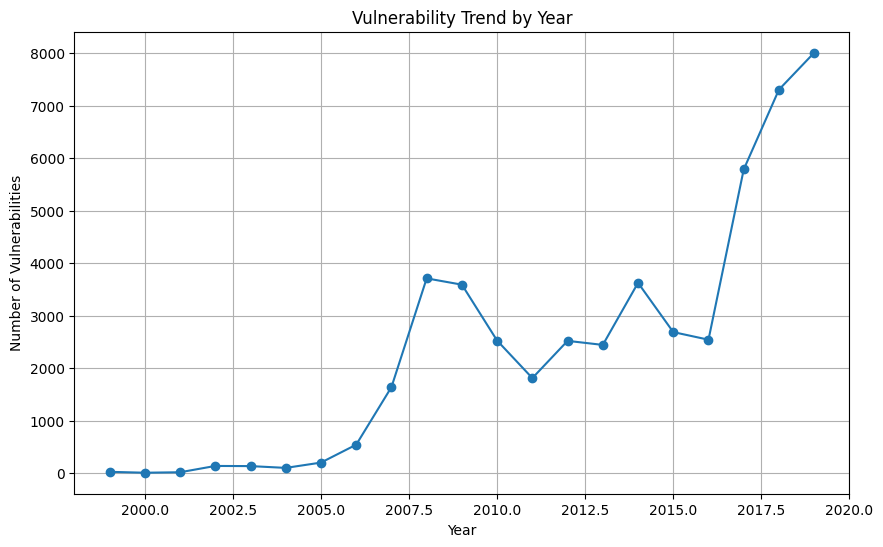

In [ ]:
# แปลงวันที่
Main_dataset["pub_date"] = pd.to_datetime(Main_dataset["pub_date"], errors="coerce")

# นับตามปี
trend = Main_dataset.groupby(Main_dataset["pub_date"].dt.year)["vuln_type"].count()

plt.figure(figsize=(10,6))
trend.plot(kind="line", marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Vulnerabilities")
plt.title("Vulnerability Trend by Year")
plt.grid(True)
plt.show()


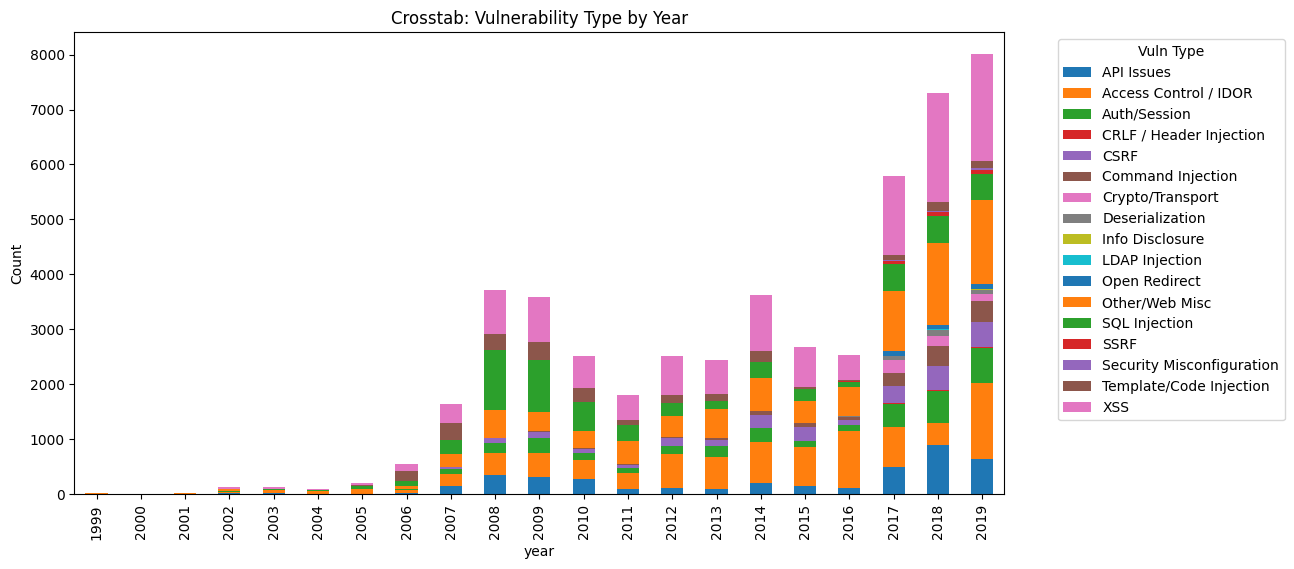

In [ ]:

Main_dataset['year'] = Main_dataset['pub_date'].dt.year
crosstab = pd.crosstab(Main_dataset["year"], Main_dataset["vuln_type"])

# วาด stacked bar
crosstab.plot(kind="bar", stacked=True, figsize=(12,6))
plt.ylabel("Count")
plt.title("Crosstab: Vulnerability Type by Year")
plt.legend(title="Vuln Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


<Figure size 2000x700 with 0 Axes>

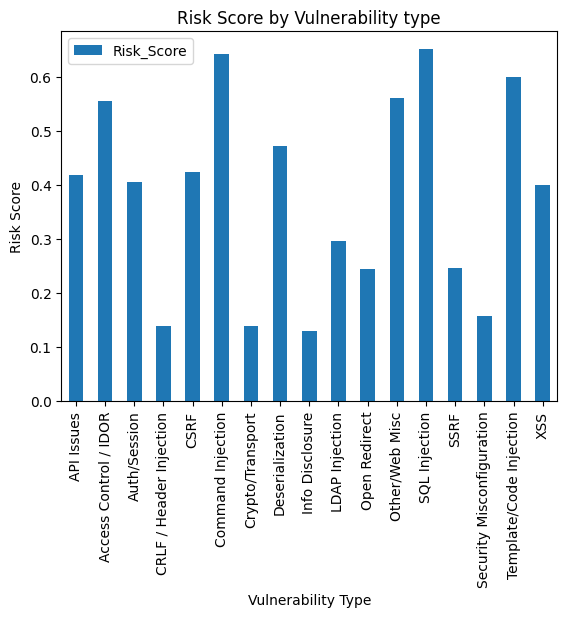

<Figure size 1000x600 with 0 Axes>

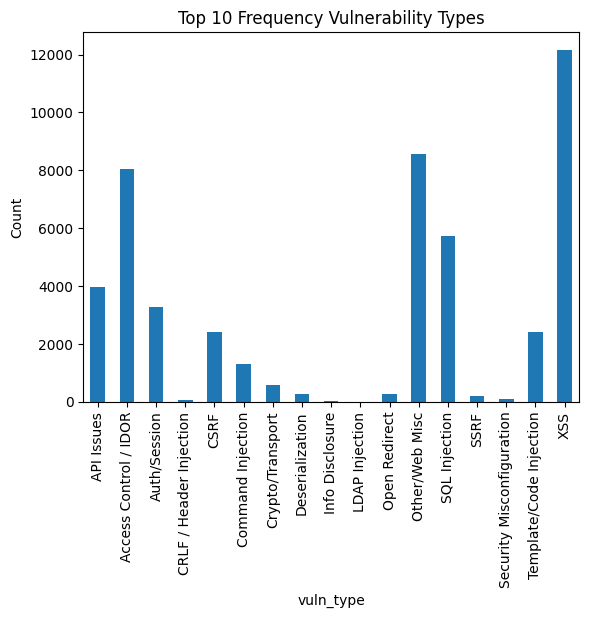

In [ ]:
plt.figure(figsize=(20,7))
type_counts.head(20).plot(kind="bar", x="vuln_type", y="Risk_Score")
plt.title("Risk Score by Vulnerability type")
plt.xlabel("Vulnerability Type")
plt.ylabel("Risk Score")
plt.show()

plt.figure(figsize=(10,6))
type_counts.head(20).plot(kind="bar", x="vuln_type", y="count", legend=False)
plt.ylabel("Count")
plt.title("Top 10 Frequency Vulnerability Types")
plt.show()


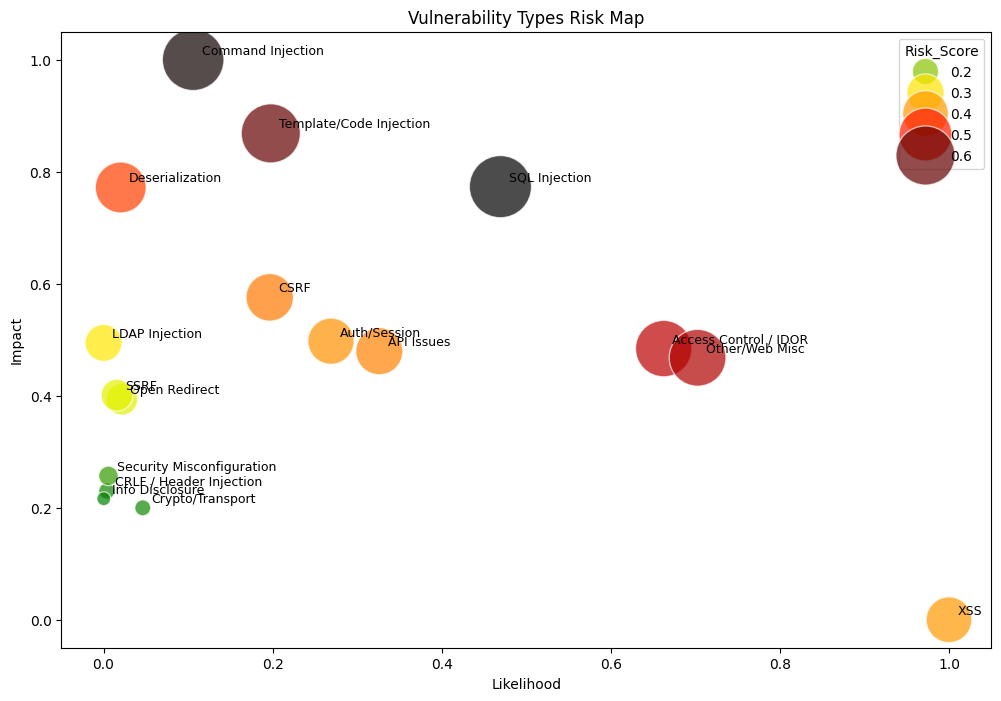

In [ ]:
# สร้าง colormap เอง ไล่เหลือง → ส้ม → แดง → ดำ
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_risk",
    ["green","yellow", "orange", "red", "black"]
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=type_counts,
    x="count_norm",
    y="cvss_avg_norm",
    size="Risk_Score",
    hue="Risk_Score",
    palette=custom_cmap,
    sizes=(100, 2000),
    alpha=0.7,
    legend="brief"
)

# เพิ่มชื่อของแต่ละจุด
for i in range(len(type_counts)):
    plt.text(
        type_counts['count_norm'][i] + 0.01,
        type_counts['cvss_avg_norm'][i] + 0.01,
        type_counts['vuln_type'][i],
        fontsize=9
    )

plt.xlabel("Likelihood")
plt.ylabel("Impact")
plt.title("Vulnerability Types Risk Map")
plt.show()


**Multivariate Analysis**

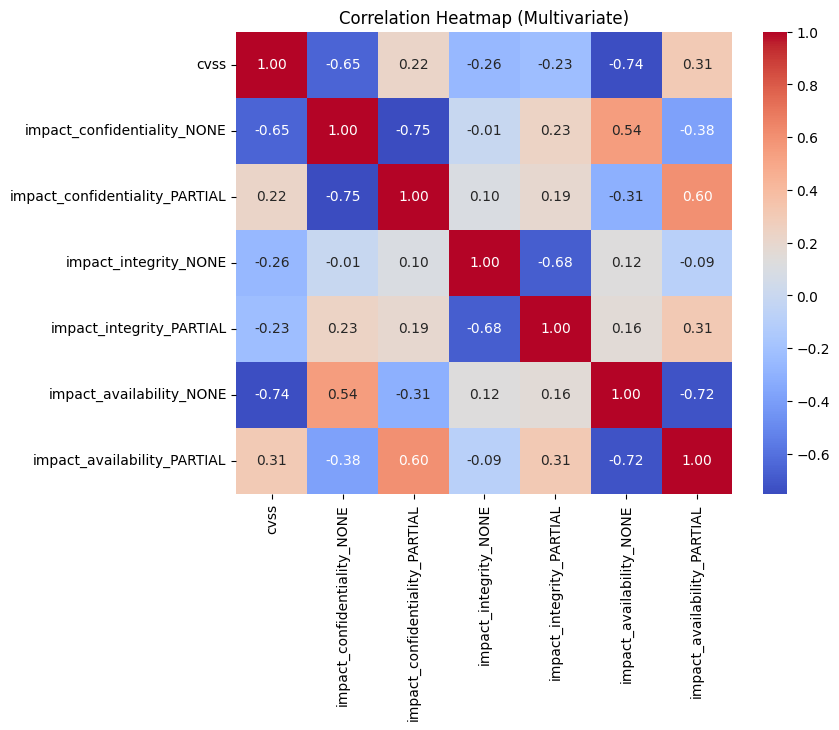

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = Main_dataset[['cvss']].join(
    pd.get_dummies(Main_dataset[['impact_confidentiality','impact_integrity','impact_availability']], drop_first=True)
).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Multivariate)")
plt.show()


Insight ที่ได้จาก Heatmap

cvss มี ความสัมพันธ์ลบสูงกับ impact_availability_NONE (-0.74) → หมายถึง ถ้า availability ไม่มีผลกระทบ คะแนน CVSS มักจะต่ำ

cvss มี ความสัมพันธ์ลบปานกลางกับ impact_confidentiality_NONE (-0.65) → ถ้า confidentiality ไม่ได้รับผลกระทบ คะแนน CVSS ก็มีแนวโน้มต่ำ

cvss มี ความสัมพันธ์บวกเล็กน้อยกับ impact_confidentiality_PARTIAL (0.22) และ impact_availability_PARTIAL (0.31) → ถ้ามีผลกระทบบางส่วน คะแนน CVSS จะสูงขึ้นเล็กน้อย

impact_confidentiality_NONE กับ impact_confidentiality_PARTIAL มีความสัมพันธ์ลบสูงมาก (-0.75) เพราะเป็น dummy variable ที่ตรงข้ามกัน

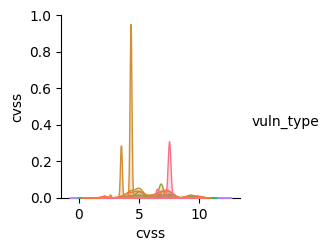

In [ ]:
sns.pairplot(Main_dataset, vars=['cvss'], hue="vuln_type", diag_kind="kde")
plt.show()


In [ ]:
df = Main_dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 49338 entries, 138 to 89642
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   pub_date                49338 non-null  datetime64[ns]
 1   mod_date                49338 non-null  datetime64[ns]
 2   cvss                    49338 non-null  float64       
 3   cwe_code                49338 non-null  int64         
 4   cwe_name                49338 non-null  object        
 5   impact_confidentiality  49338 non-null  object        
 6   impact_integrity        49338 non-null  object        
 7   impact_availability     49338 non-null  object        
 8   access_vector           49338 non-null  object        
 9   access_complexity       49338 non-null  object        
 10  access_authentication   49338 non-null  object        
 11  summary                 49338 non-null  object        
 12  severity                49338 non-null  object   

# **Logistic Regession**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =====================================================
# 0) เตรียมข้อมูลพื้นฐาน: สร้าง year และกรองเฉพาะ SQLi / XSS / CSRF
# =====================================================

# เผื่อยังไม่ได้แปลง pub_date
Main_dataset["pub_date"] = pd.to_datetime(Main_dataset["pub_date"], errors="coerce")
Main_dataset["year"] = Main_dataset["pub_date"].dt.year

focus_types = ["SQL Injection", "XSS", "CSRF"]

df_focus = Main_dataset[Main_dataset["vuln_type"].isin(focus_types)].copy()

# =====================================================
# 1) Groupby: vuln_type + year -> count
# =====================================================

yearly = (
    df_focus
    .groupby(["vuln_type", "year"])
    .size()
    .reset_index(name="count")
    .sort_values(["vuln_type", "year"])
)

print("=== YEARLY COUNT (SQLi / XSS / CSRF) ===")
print(yearly.head(20))

# =====================================================
# 2) แบ่ง 2 class: LOW / HIGH ต่อ vuln_type
#    ใช้เกณฑ์ = ค่าเฉลี่ยของ count ในแต่ละ vuln_type
#    label = 0 (LOW), 1 (HIGH)
# =====================================================

# คำนวณ threshold (mean ของ count แยกตาม vuln_type), Feature Engineering (สร้าง Feature ใหม่)
yearly["threshold"] = yearly.groupby("vuln_type")["count"].transform("mean")

# กำหนด label: ถ้า count >= threshold → HIGH (1), ถ้าน้อยกว่า → LOW (0)
yearly["label"] = np.where(yearly["count"] >= yearly["threshold"], 1, 0)

print("\n=== YEARLY WITH HIGH/LOW LABEL ===")
print(yearly)

# แยกดูแต่ละประเภท (ถ้าอยาก inspect เพิ่มเติม)
yearly_sql  = yearly[yearly["vuln_type"] == "SQL Injection"]
yearly_xss  = yearly[yearly["vuln_type"] == "XSS"]
yearly_csrf = yearly[yearly["vuln_type"] == "CSRF"]

print("\n--- SQL Injection (Yearly + Label) ---")
print(yearly_sql)

print("\n--- XSS (Yearly + Label) ---")
print(yearly_xss)

print("\n--- CSRF (Yearly + Label) ---")
print(yearly_csrf)

# =====================================================
# 3) เตรียมชุดข้อมูลสำหรับทำโมเดล
#    Feature selection: vuln_type, count, year
#    Target: label (0 = LOW, 1 = HIGH)
# =====================================================

#Feature Selection (เลือก Features ที่ใช้เทรนโมเดล)
X = yearly[["vuln_type", "year", "count"]].copy()
y = yearly["label"].values

# เข้ารหัส vuln_type เป็นตัวเลข
le_type = LabelEncoder()
X["vuln_type"] = le_type.fit_transform(X["vuln_type"])

# แบ่ง train / test ตามปี (เช่นใช้ปีล่าสุดเป็น test)
max_year = yearly["year"].max()
test_year = max_year  # ถ้าอยากเปลี่ยนก็เปลี่ยนตัวนี้ได้

train_idx = yearly["year"] < test_year
test_idx  = yearly["year"] == test_year

X_train = X[train_idx].values
y_train = y[train_idx]

X_test  = X[test_idx].values
y_test  = y[test_idx]

print(f"\nTrain years < {test_year}, Test year = {test_year}")
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test) if X_test.shape[0] > 0 else None

# =====================================================
#  Train Logistic Regression (2-class: LOW vs HIGH)
# =====================================================

model = LogisticRegression(max_iter=1000)
model.fit(X_train_sc, y_train)

print("\n=== Logistic Regression (2-class: LOW/HIGH) ===")
if X_test_sc is not None and X_test_sc.shape[0] > 0:
    y_pred = model.predict(X_test_sc)
    print(f"Test Accuracy (year = {test_year}): {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
else:
    print("No test data (check year split).")

# =====================================================
# 5) ฟังก์ชัน Rolling Evaluation (2-class) แบบใช้ yearly dataset
#    (Time-series: ทดสอบทีละปี โดย train จากปีก่อนหน้า)
# =====================================================

def rolling_eval_yearly_2class(yearly_df, min_train_years=2):
    """
    ใช้ feature: vuln_type, year, count
    target: label (0 = LOW, 1 = HIGH)
    ทำ rolling evaluation ตามปี
    """
    df = yearly_df.copy()

    # เตรียม X, y
    X_all = df[["vuln_type", "year", "count"]].copy()
    y_all = df["label"].values

    le = LabelEncoder()
    X_all["vuln_type"] = le.fit_transform(X_all["vuln_type"])

    years = sorted(df["year"].unique())
    results = []

    print("\n=== ROLLING EVAL (2-class HIGH/LOW) ON YEARLY DATA ===")
    for y in years:
        train_mask = df["year"] < y
        test_mask  = df["year"] == y

        # ปี train ต้องมีอย่างน้อย min_train_years ปี + ต้องมี test data
        if (
            len(df[train_mask]["year"].unique()) < min_train_years or
            test_mask.sum() == 0
        ):
            # print(f"Skip year {y} : train_years={len(df[train_mask]['year'].unique())}, test_size={test_mask.sum()}")
            continue

        # เช็คจำนวนคลาสใน y_train ก่อน (สำคัญมาก กัน error)
        y_train = y_all[train_mask]
        if len(np.unique(y_train)) < 2:
            # print(f"Skip year {y} : only one class in y_train -> {np.unique(y_train)}")
            continue

        X_train = X_all[train_mask].values
        X_test  = X_all[test_mask].values
        y_test  = y_all[test_mask]

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train_sc, y_train)

        y_pred = model.predict(X_test_sc)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "year": y,
            "train_years": len(df[train_mask]["year"].unique()),
            "test_size": X_test.shape[0],
            "train_classes": list(np.unique(y_train)),
            "acc": acc
        })

    res = pd.DataFrame(results)
    print(res)
    return res


# เรียกใช้ Rolling Eval
rolling_results = rolling_eval_yearly_2class(yearly)


=== YEARLY COUNT (SQLi / XSS / CSRF) ===
        vuln_type  year  count
0            CSRF  2002      1
1            CSRF  2005      1
2            CSRF  2006      3
3            CSRF  2007     35
4            CSRF  2008     76
5            CSRF  2009    113
6            CSRF  2010     75
7            CSRF  2011     55
8            CSRF  2012    153
9            CSRF  2013    120
10           CSRF  2014    243
11           CSRF  2015    241
12           CSRF  2016     81
13           CSRF  2017    308
14           CSRF  2018    440
15           CSRF  2019    455
16  SQL Injection  2002      7
17  SQL Injection  2003     11
18  SQL Injection  2004      9
19  SQL Injection  2005     50

=== YEARLY WITH HIGH/LOW LABEL ===
        vuln_type  year  count   threshold  label
0            CSRF  2002      1  150.000000      0
1            CSRF  2005      1  150.000000      0
2            CSRF  2006      3  150.000000      0
3            CSRF  2007     35  150.000000      0
4            CSRF  200

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
print("\n=== Classification Report (All Years) by Vulnerability Type ===")

for vuln_type_name in focus_types:
    print(f"\n>>> {vuln_type_name} <<<")

    # Filter เฉพาะ type นั้น
    df_current = yearly[yearly["vuln_type"] == vuln_type_name].copy()
    if df_current.empty:
        print("No data for this type.")
        continue

    # Prepare X, y
    X_current = df_current[["vuln_type", "year", "count"]].copy()
    y_current = df_current["label"].values

    # Encode vuln_type
    X_current["vuln_type"] = le_type.transform(X_current["vuln_type"])

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_current)

    # Train model on ALL YEARS
    model_type = LogisticRegression(max_iter=1000)
    model_type.fit(X_scaled, y_current)

    # Predict on ALL YEARS
    y_pred = model_type.predict(X_scaled)

    # 🔥 เพิ่ม Accuracy
    acc = (y_pred == y_current).mean()
    print(f"Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(
        y_current,
        y_pred,
        labels=[0, 1],
        digits=4,
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(
        y_current,
        y_pred,
        labels=[0, 1]
    ))



=== Classification Report (All Years) by Vulnerability Type ===

>>> SQL Injection <<<
Accuracy: 0.9444
Classification Report:
              precision    recall  f1-score   support

           0     0.9231    1.0000    0.9600        12
           1     1.0000    0.8333    0.9091         6

    accuracy                         0.9444        18
   macro avg     0.9615    0.9167    0.9345        18
weighted avg     0.9487    0.9444    0.9430        18

Confusion Matrix:
[[12  0]
 [ 1  5]]

>>> XSS <<<
Accuracy: 0.9474
Classification Report:
              precision    recall  f1-score   support

           0     0.9167    1.0000    0.9565        11
           1     1.0000    0.8750    0.9333         8

    accuracy                         0.9474        19
   macro avg     0.9583    0.9375    0.9449        19
weighted avg     0.9518    0.9474    0.9468        19

Confusion Matrix:
[[11  0]
 [ 1  7]]

>>> CSRF <<<
Accuracy: 0.9375
Classification Report:
              precision    recall  f1

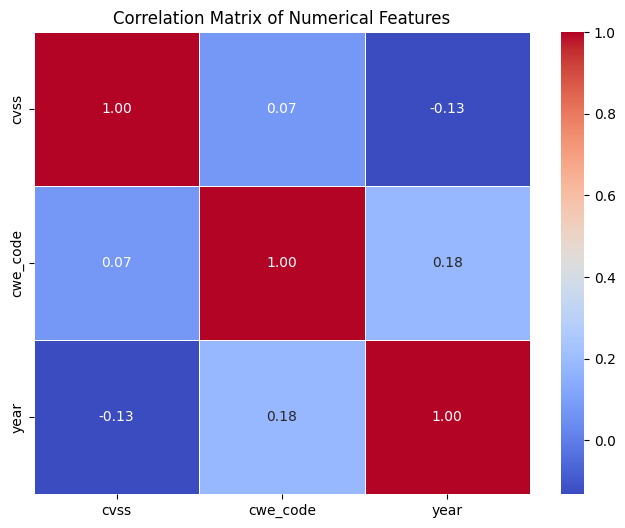

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for correlation matrix
numerical_cols = ['cvss', 'cwe_code', 'year']

# Calculate the correlation matrix
correlation_matrix = Main_dataset[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()





# **NAVIE**

## Preprocessing

In [ ]:
#เซลล์มี่1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

focus_types = ["SQL Injection", "XSS", "CSRF"]
df = Main_dataset[Main_dataset["vuln_type"].isin(focus_types)].copy()
yearly = df.groupby(["vuln_type", "year"]).size().reset_index(name="count")

print(yearly[ yearly["vuln_type"] == "CSRF" ])
print(yearly[ yearly["vuln_type"] == "SQL Injection" ])
print(yearly[ yearly["vuln_type"] == "XSS" ])

   vuln_type  year  count
0       CSRF  2002      1
1       CSRF  2005      1
2       CSRF  2006      3
3       CSRF  2007     35
4       CSRF  2008     76
5       CSRF  2009    113
6       CSRF  2010     75
7       CSRF  2011     55
8       CSRF  2012    153
9       CSRF  2013    120
10      CSRF  2014    243
11      CSRF  2015    241
12      CSRF  2016     81
13      CSRF  2017    308
14      CSRF  2018    440
15      CSRF  2019    455
        vuln_type  year  count
16  SQL Injection  2002      7
17  SQL Injection  2003     11
18  SQL Injection  2004      9
19  SQL Injection  2005     50
20  SQL Injection  2006     97
21  SQL Injection  2007    254
22  SQL Injection  2008   1091
23  SQL Injection  2009    948
24  SQL Injection  2010    515
25  SQL Injection  2011    288
26  SQL Injection  2012    236
27  SQL Injection  2013    146
28  SQL Injection  2014    295
29  SQL Injection  2015    213
30  SQL Injection  2016     91
31  SQL Injection  2017    500
32  SQL Injection  2018    502


In [ ]:
# ใช้ yearly จากโค้ดเดิม
df = yearly.copy()

# pivot ให้เห็นจำนวนในแต่ละปีชัดขึ้น
pivot_df = df.pivot(index="year", columns="vuln_type", values="count").fillna(0)

# สร้าง lag features
pivot_df["prev1"] = pivot_df["SQL Injection"].shift(1)
pivot_df["prev2"] = pivot_df["SQL Injection"].shift(2)
pivot_df["prev3"] = pivot_df["SQL Injection"].shift(3)

pivot_df = pivot_df.dropna()
pivot_df.head()


vuln_type,CSRF,SQL Injection,XSS,prev1,prev2,prev3
year,,,,,,
2004,0.0,9.0,22.0,11.0,7.0,0.0
2005,1.0,50.0,35.0,9.0,11.0,7.0
2006,3.0,97.0,114.0,50.0,9.0,11.0
2007,35.0,254.0,350.0,97.0,50.0,9.0
2008,76.0,1091.0,788.0,254.0,97.0,50.0


In [ ]:
#เซลล์มี่3
threshold = pivot_df["SQL Injection"].median()

pivot_df["label"] = np.where(
    pivot_df["SQL Injection"] >= threshold,
    "High",
    "Low"
)


## Modeling

In [ ]:
#เซลล์มี่4
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = pivot_df[["prev1", "prev2", "prev3"]]
y = pivot_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



print("=== SQL Injection Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))


=== SQL Injection Model ===
Accuracy: 1.0

Confusion Matrix:
 [[2 0]
 [0 2]]

Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
#เซลล์มี่5
# ------------------------------------
# MODEL: XSS
# ------------------------------------

df_xss = yearly[yearly["vuln_type"] == "XSS"].copy()

pivot_xss = df_xss.pivot(
    index="year",
    columns="vuln_type",
    values="count"
).fillna(0)

# สร้าง lag features ของ XSS
pivot_xss["prev1"] = pivot_xss["XSS"].shift(1)
pivot_xss["prev2"] = pivot_xss["XSS"].shift(2)
pivot_xss["prev3"] = pivot_xss["XSS"].shift(3)

pivot_xss = pivot_xss.dropna()

# Label High/Low
threshold_xss = pivot_xss["XSS"].median()
pivot_xss["label"] = np.where(
    pivot_xss["XSS"] >= threshold_xss,
    "High",
    "Low"
)

# Prepare X,y
X = pivot_xss[["prev1", "prev2", "prev3"]]
y = pivot_xss["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model_xss = GaussianNB()
model_xss.fit(X_train, y_train)

pred_xss = model_xss.predict(X_test)

print("XSS Accuracy:", accuracy_score(y_test, pred_xss))
print("\nXSS Confusion Matrix:\n", confusion_matrix(y_test, pred_xss))
print("\nXSS Report:\n", classification_report(y_test, pred_xss))


XSS Accuracy: 0.75

XSS Confusion Matrix:
 [[1 1]
 [0 2]]

XSS Report:
               precision    recall  f1-score   support

        High       1.00      0.50      0.67         2
         Low       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [ ]:
#เซลล์ที่6
# ------------------------------------
# MODEL: CSRF
# ------------------------------------

df_csrf = yearly[yearly["vuln_type"] == "CSRF"].copy()

pivot_csrf = df_csrf.pivot(
    index="year",
    columns="vuln_type",
    values="count"
).fillna(0)

# สร้าง lag features ของ CSRF
pivot_csrf["prev1"] = pivot_csrf["CSRF"].shift(1)
pivot_csrf["prev2"] = pivot_csrf["CSRF"].shift(2)
pivot_csrf["prev3"] = pivot_csrf["CSRF"].shift(3)

pivot_csrf = pivot_csrf.dropna()

# Label High/Low
threshold_csrf = pivot_csrf["CSRF"].median()
pivot_csrf["label"] = np.where(
    pivot_csrf["CSRF"] >= threshold_csrf,
    "High",
    "Low"
)

# Prepare X,y
X = pivot_csrf[["prev1", "prev2", "prev3"]]
y = pivot_csrf["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model_csrf = GaussianNB()
model_csrf.fit(X_train, y_train)

pred_csrf = model_csrf.predict(X_test)

print("CSRF Accuracy:", accuracy_score(y_test, pred_csrf))
print("\nCSRF Confusion Matrix:\n", confusion_matrix(y_test, pred_csrf))
print("\nCSRF Report:\n", classification_report(y_test, pred_csrf))


CSRF Accuracy: 0.75

CSRF Confusion Matrix:
 [[2 0]
 [1 1]]

CSRF Report:
               precision    recall  f1-score   support

        High       0.67      1.00      0.80         2
         Low       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



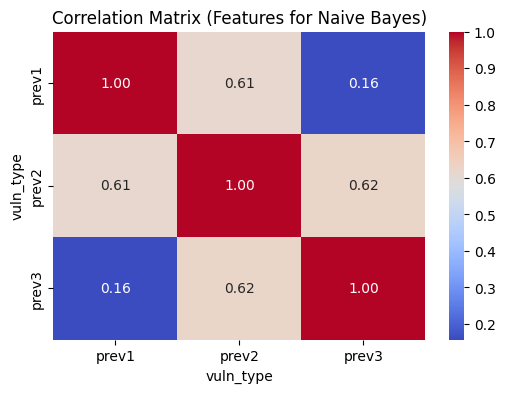

In [ ]:
# Correlation Matrix for Naive Bayes features
import seaborn as sns
import matplotlib.pyplot as plt

corr_nb = pivot_df[["prev1", "prev2", "prev3"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_nb, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Features for Naive Bayes)")
plt.show()


# **KNN**

## Preprocessing

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

focus_types = ["SQL Injection", "XSS", "CSRF"]
df = Main_dataset[Main_dataset["vuln_type"].isin(focus_types)].copy()
yearly = df.groupby(["vuln_type", "year"]).size().reset_index(name="count")

print(yearly[ yearly["vuln_type"] == "CSRF" ])
print(yearly[ yearly["vuln_type"] == "SQL Injection" ])
print(yearly[ yearly["vuln_type"] == "XSS" ])


   vuln_type  year  count
0       CSRF  2002      1
1       CSRF  2005      1
2       CSRF  2006      3
3       CSRF  2007     35
4       CSRF  2008     76
5       CSRF  2009    113
6       CSRF  2010     75
7       CSRF  2011     55
8       CSRF  2012    153
9       CSRF  2013    120
10      CSRF  2014    243
11      CSRF  2015    241
12      CSRF  2016     81
13      CSRF  2017    308
14      CSRF  2018    440
15      CSRF  2019    455
        vuln_type  year  count
16  SQL Injection  2002      7
17  SQL Injection  2003     11
18  SQL Injection  2004      9
19  SQL Injection  2005     50
20  SQL Injection  2006     97
21  SQL Injection  2007    254
22  SQL Injection  2008   1091
23  SQL Injection  2009    948
24  SQL Injection  2010    515
25  SQL Injection  2011    288
26  SQL Injection  2012    236
27  SQL Injection  2013    146
28  SQL Injection  2014    295
29  SQL Injection  2015    213
30  SQL Injection  2016     91
31  SQL Injection  2017    500
32  SQL Injection  2018    502


## Modeling

In [ ]:

for v in focus_types:
    print(f"\n=== {v} ===")

    dfv = yearly[ yearly["vuln_type"] == v ].copy()
    dfv = dfv.sort_values("year")

    # Create lag features (3-year history)
    dfv["lag1"] = dfv["count"].shift(1)
    dfv["lag2"] = dfv["count"].shift(2)
    dfv["lag3"] = dfv["count"].shift(3)
    dfv.fillna(0, inplace=True)


    dfv["label"] = (dfv["count"] > dfv[["lag1","lag2","lag3"]].median(axis=1)).astype(int)
    X = dfv[["lag1","lag2","lag3","count"]] #Neighbor อิงจาก lag123 count คือ ปีที่ดู
    y = dfv["label"] #label เป็น 1 ก็ต่อเมื่อ count > median(lag123)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))




=== SQL Injection ===
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6


=== XSS ===
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.83      1.00      0.91         5

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6


=== CSRF ===
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.80      1.00      0.89         4

    accuracy                           0.80         5
   mac

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
print("[Confusion Matrix]")
print(confusion_matrix(y_test, pred))

[Confusion Matrix]
[[0 1]
 [0 4]]



Nearest Neighbors for year 2019
    year  count
17  2018   1984
16  2017   1438
13  2014   1025
8   2009    821
7   2008    788


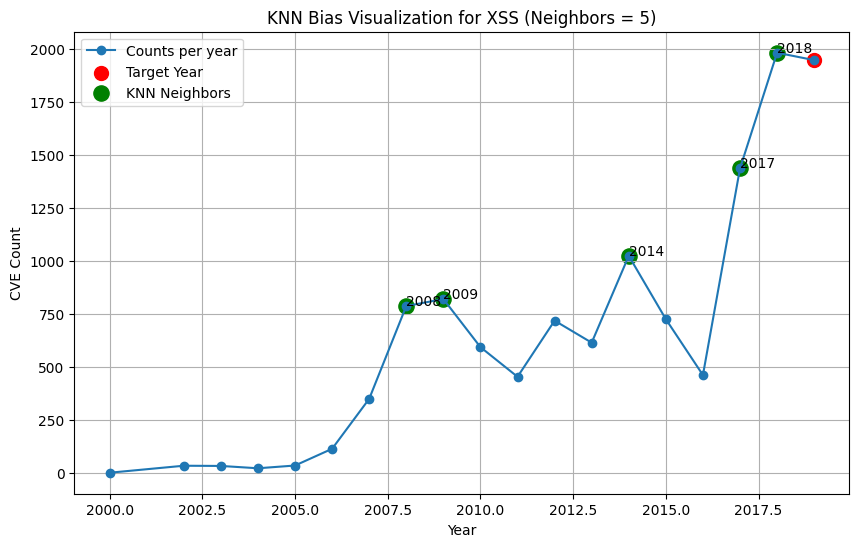

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# ---- ใช้ข้อมูล yearly (หลัง preprocess) ----
yearly = df.groupby(["vuln_type", "year"]).size().reset_index(name="count")

# ---- เลือก 1 type ตัวอย่าง เช่น XSS ----
vuln = "XSS"
df_t = yearly[ yearly["vuln_type"] == vuln ].sort_values("year").reset_index(drop=True)

# ---- เลือกปีที่จะตรวจสอบ neighbors ----
target_year = 2019
k = 5  # neighbors

row_target = df_t[df_t["year"] == target_year]

if len(row_target) == 0:
    print("ปีนี้ไม่มีข้อมูล")
else:
    X = df_t[["count"]].values
    neigh = NearestNeighbors(n_neighbors=k+1)  # +1 รวมตัวเองด้วย
    neigh.fit(X)

    target_index = row_target.index[0]
    distances, indices = neigh.kneighbors([row_target["count"].values])

    # remove ตัวเอง
    neighbor_indices = indices[0][1:]

    print("\nNearest Neighbors for year", target_year)
    print(df_t.iloc[neighbor_indices][["year", "count"]])

    # ------------- PLOT GRAPH -------------
    plt.figure(figsize=(10,6))

    # Plot timeline counts
    plt.plot(df_t["year"], df_t["count"], marker='o', label="Counts per year")

    # Highlight target year
    plt.scatter(row_target["year"], row_target["count"], color="red", s=100, label="Target Year")

    # Highlight neighbors
    plt.scatter(df_t.iloc[neighbor_indices]["year"], df_t.iloc[neighbor_indices]["count"],
                color="green", s=120, label="KNN Neighbors")

    for i in neighbor_indices:
        plt.annotate(df_t.iloc[i]["year"],
                     (df_t.iloc[i]["year"], df_t.iloc[i]["count"] + 3))

    plt.title(f"KNN Bias Visualization for {vuln} (Neighbors = {k})")
    plt.xlabel("Year")
    plt.ylabel("CVE Count")
    plt.legend()
    plt.grid(True)
    plt.show()



Nearest Neighbors for year 2019
    year  count
15  2017    500
16  2018    502
8   2010    515
12  2014    295
9   2011    288


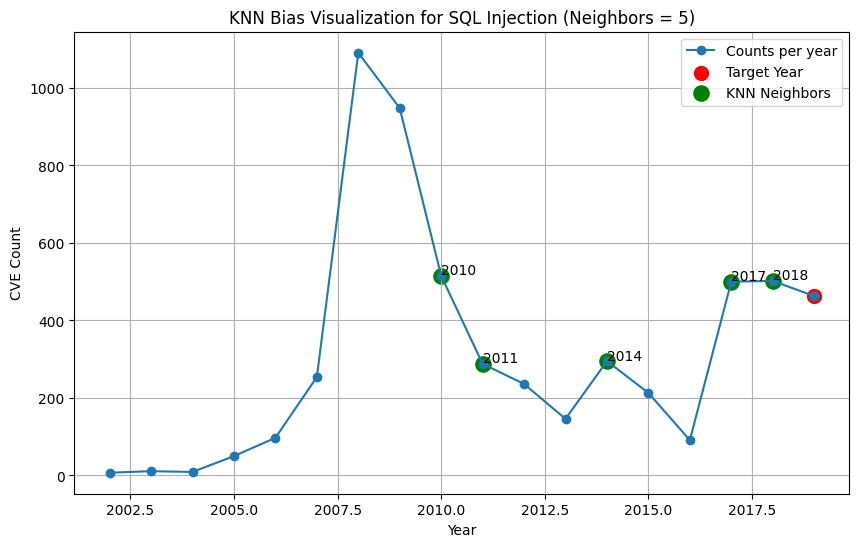

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# ---- ใช้ข้อมูล yearly (หลัง preprocess) ----
yearly = df.groupby(["vuln_type", "year"]).size().reset_index(name="count")

# ---- เลือก 1 type ตัวอย่าง เช่น XSS ----
vuln = "SQL Injection"
df_t = yearly[ yearly["vuln_type"] == vuln ].sort_values("year").reset_index(drop=True)

# ---- เลือกปีที่จะตรวจสอบ neighbors ----
target_year = 2019
k = 5  # neighbors

row_target = df_t[df_t["year"] == target_year]

if len(row_target) == 0:
    print("ปีนี้ไม่มีข้อมูล")
else:
    X = df_t[["count"]].values
    neigh = NearestNeighbors(n_neighbors=k+1)  # +1 รวมตัวเองด้วย
    neigh.fit(X)

    target_index = row_target.index[0]
    distances, indices = neigh.kneighbors([row_target["count"].values])

    # remove ตัวเอง
    neighbor_indices = indices[0][1:]

    print("\nNearest Neighbors for year", target_year)
    print(df_t.iloc[neighbor_indices][["year", "count"]])

    # ------------- PLOT GRAPH -------------
    plt.figure(figsize=(10,6))

    # Plot timeline counts
    plt.plot(df_t["year"], df_t["count"], marker='o', label="Counts per year")

    # Highlight target year
    plt.scatter(row_target["year"], row_target["count"], color="red", s=100, label="Target Year")

    # Highlight neighbors
    plt.scatter(df_t.iloc[neighbor_indices]["year"], df_t.iloc[neighbor_indices]["count"],
                color="green", s=120, label="KNN Neighbors")

    for i in neighbor_indices:
        plt.annotate(df_t.iloc[i]["year"],
                     (df_t.iloc[i]["year"], df_t.iloc[i]["count"] + 3))

    plt.title(f"KNN Bias Visualization for {vuln} (Neighbors = {k})")
    plt.xlabel("Year")
    plt.ylabel("CVE Count")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# ---- Correlation Matrix ----
corr = dfv[["lag1","lag2","lag3","count"]].corr()
print("\nCorrelation Matrix:")
print(corr)



Correlation Matrix:
           lag1      lag2      lag3     count
lag1   1.000000  0.727828  0.541248  0.808598
lag2   0.727828  1.000000  0.586550  0.668157
lag3   0.541248  0.586550  1.000000  0.728634
count  0.808598  0.668157  0.728634  1.000000


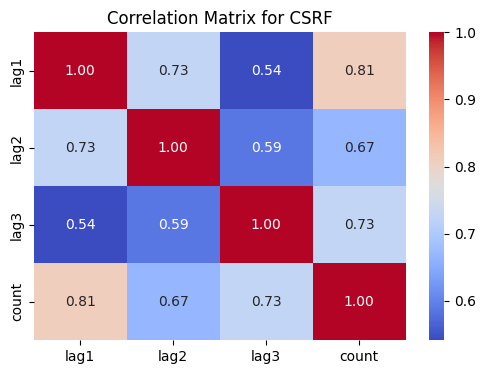

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title(f"Correlation Matrix for {v}")
plt.show()


In [ ]:
print("\n📊 ผลการประเมินผลด้วย Test Set (ข้อมูลที่ไม่เคยเห็นมาก่อน)")
y_pred = pred.predict(X_test)


📊 ผลการประเมินผลด้วย Test Set (ข้อมูลที่ไม่เคยเห็นมาก่อน)


AttributeError: 'numpy.ndarray' object has no attribute 'predict'

In [ ]:
print("[Confusion Matrix]")
print(confusion_matrix(y_test, y_with_fs_pred))

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names=None, figsize=(6,4)):
    """
    y_true: ค่าจริง (Ground truth)
    y_pred: ค่าที่โมเดลทำนาย
    class_names: รายชื่อ class (list)
    figsize: ขนาดรูป

    ใช้สำหรับวาด confusion matrix visualization
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix Visualization")
    plt.show()

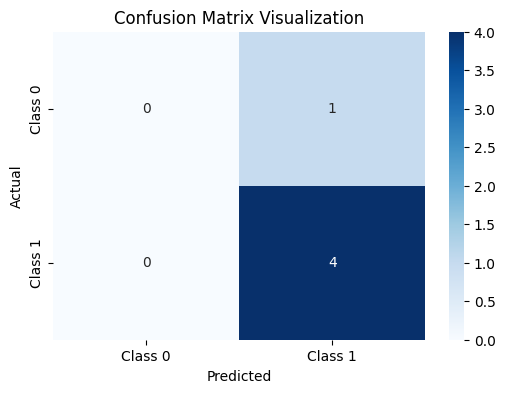

In [ ]:
class_names = ["Class 0", "Class 1"]
plot_confusion_matrix(y_test, pred, class_names)

In [ ]:
print("[Classification Report]")
print(classification_report(y_with_fs_test, y_with_fs_pred))

## Summary

สรุปคือ KNN เป็น model ที่ไม่เหมาะกับการทำ Forecast อนาคต เพราะ


1.   มันไม่เข้าใจ Time-line
2.   มันเลือก Neighbor โดยดูจากทุกปีและเลือกตัวที่ใกล้เคียงมันมากที่สุดมาเป็น Neighbor ทำให้ข้อมูลมี Bias มากเกินไป

จึงเป็น Model ที่เหมาะสำหรับจัดเข้า Class มากกว่า Forecasting and Predicting

In [ ]:
print(yearly.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   vuln_type  53 non-null     object
 1   year       53 non-null     int32 
 2   count      53 non-null     int64 
dtypes: int32(1), int64(1), object(1)
memory usage: 1.2+ KB
None


In [ ]:
print(yearly)

        vuln_type  year  count
0            CSRF  2002      1
1            CSRF  2005      1
2            CSRF  2006      3
3            CSRF  2007     35
4            CSRF  2008     76
5            CSRF  2009    113
6            CSRF  2010     75
7            CSRF  2011     55
8            CSRF  2012    153
9            CSRF  2013    120
10           CSRF  2014    243
11           CSRF  2015    241
12           CSRF  2016     81
13           CSRF  2017    308
14           CSRF  2018    440
15           CSRF  2019    455
16  SQL Injection  2002      7
17  SQL Injection  2003     11
18  SQL Injection  2004      9
19  SQL Injection  2005     50
20  SQL Injection  2006     97
21  SQL Injection  2007    254
22  SQL Injection  2008   1091
23  SQL Injection  2009    948
24  SQL Injection  2010    515
25  SQL Injection  2011    288
26  SQL Injection  2012    236
27  SQL Injection  2013    146
28  SQL Injection  2014    295
29  SQL Injection  2015    213
30  SQL Injection  2016     91
31  SQL 

In [ ]:
print(yearly['year'].unique())
print(yearly['year'].dtype)

[2002 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2003 2004 2000]
int32


# **ARIMA**

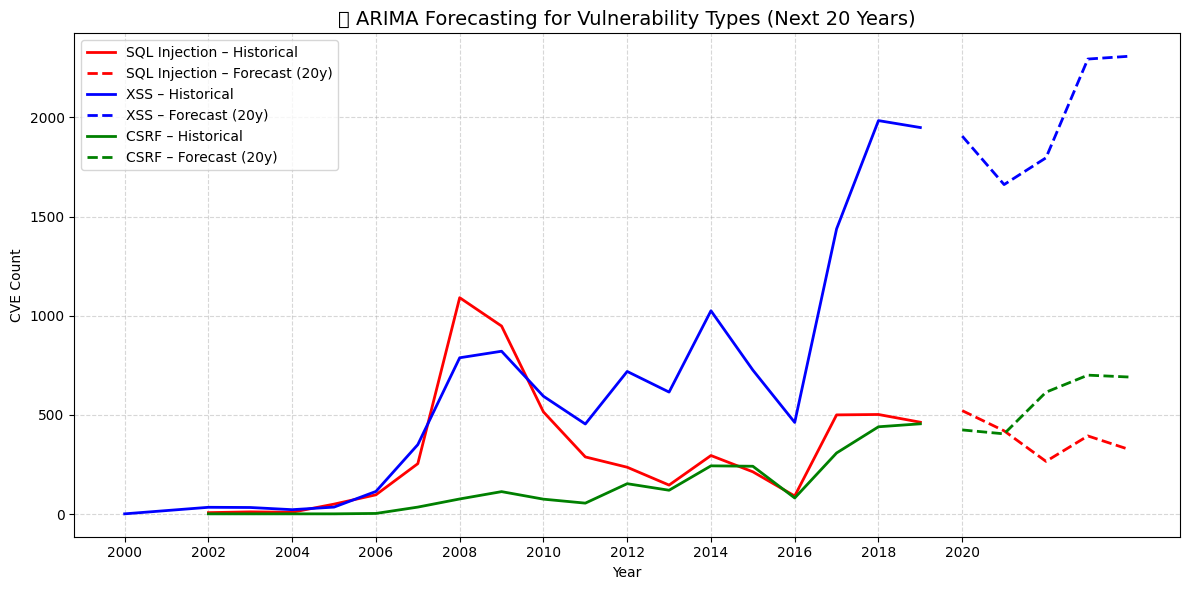

In [ ]:
# ===========================================
# 🔥 ARIMA Forecasting for SQLi, XSS, CSRF (20 Years Ahead)
# ===========================================
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Load only SQLi, XSS, CSRF
# -------------------------------
focus_types = ["SQL Injection", "XSS", "CSRF"]
colors = {"SQL Injection": "red", "XSS": "blue", "CSRF": "green"}   # custom colors
df = Main_dataset[Main_dataset["vuln_type"].isin(focus_types)].copy()

# -------------------------------
# Count CVE per year per type
# -------------------------------
yearly = df.groupby(["vuln_type", "year"]).size().reset_index(name="count")

# -------------------------------
# Forecast results
# -------------------------------
forecast_results = {}

plt.figure(figsize=(12,6))  # big figure for all lines

for vuln in focus_types:
    df_type = yearly[yearly["vuln_type"] == vuln][["year", "count"]].set_index("year")

    # Fit ARIMA model
    model = ARIMA(df_type["count"], order=(5,1,5))
    model_fit = model.fit()

    # Forecast next 20 years
    future = model_fit.forecast(steps=5)
    forecast_results[vuln] = future

    # Plot historical
    plt.plot(df_type.index,
             df_type["count"],
             label=f"{vuln} – Historical",
             color=colors[vuln],
             linewidth=2)

    # Plot forecast
    future_years = range(df_type.index.max()+1, df_type.index.max()+6)
    plt.plot(future_years,
             future,
             linestyle="--",
             color=colors[vuln],
             linewidth=2,
             label=f"{vuln} – Forecast (20y)")

# -------------------------------
# Final Graph Styling
# -------------------------------
plt.title("📈 ARIMA Forecasting for Vulnerability Types (Next 20 Years)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("CVE Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.xticks(range(yearly["year"].min(), yearly["year"].max()+2, 2))
plt.tight_layout()
plt.show()


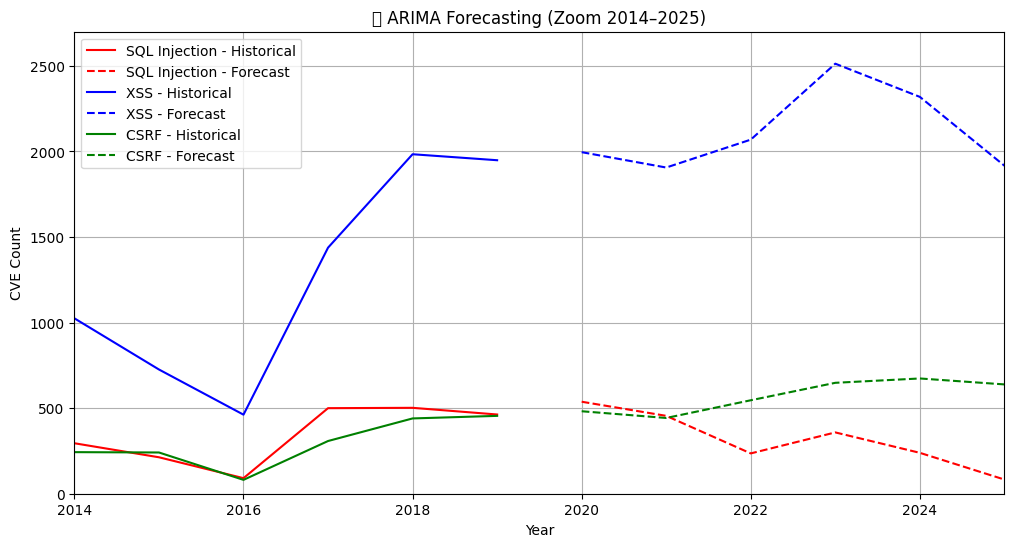

In [ ]:
# ===========================================
# 🔥 ARIMA Forecasting for CVE Vulnerabilities
#         (Zoom 2014–2025)
# ===========================================
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

focus_types = ["SQL Injection", "XSS", "CSRF"]
df = Main_dataset[Main_dataset["vuln_type"].isin(focus_types)].copy()

yearly = df.groupby(["vuln_type", "year"]).size().reset_index(name="count")

forecast_horizon = 20
forecast_results = {}

plt.figure(figsize=(12,6))

colors = {
    "SQL Injection": "red",
    "XSS": "blue",
    "CSRF": "green"
}

for vuln in focus_types:

    df_type = yearly[yearly["vuln_type"] == vuln][["year","count"]].set_index("year")

    model = ARIMA(df_type["count"], order=(10,1,10))
    fit = model.fit()

    future = fit.forecast(steps=forecast_horizon)
    forecast_results[vuln] = future

    # Actual years + forecast years
    future_years = range(df_type.index.max()+1, df_type.index.max()+forecast_horizon+1)

    # Plot historical
    plt.plot(df_type.index, df_type["count"],
             label=f"{vuln} - Historical",
             color=colors[vuln])

    # Plot forecast
    plt.plot(future_years, future,
             label=f"{vuln} - Forecast",
             linestyle="--",
             color=colors[vuln])

# 🔍 Zoom to 2014–2025
plt.xlim(2014, 2025)
plt.ylim(0, 2700)   # ทำให้กราฟเตี้ยลง

plt.title("🔎 ARIMA Forecasting (Zoom 2014–2025)")
plt.xlabel("Year")
plt.ylabel("CVE Count")
plt.grid(True)
plt.legend()
plt.show()
